EXPLORATORY DATA ANALYSIS (EDA)

In [11]:
#reading the cleaned dataset
import pandas as pd

df_clean = pd.read_csv("../data/cleaned_air_quality.csv")
df_clean.head()

,City,Date,PM2.5,PM10,NO2,CO,SO2,O3,AQI,AQI_Bucket,Year
0,Ahmedabad,2015-01-29,83.13,96.18,28.71,6.93,49.52,59.76,209.0,Poor,2015
1,Ahmedabad,2015-01-30,79.84,96.18,28.68,13.85,48.49,97.07,328.0,Very Poor,2015
2,Ahmedabad,2015-01-31,94.52,96.18,32.66,24.39,67.39,111.33,514.0,Severe,2015
3,Ahmedabad,2015-02-01,135.99,96.18,42.08,43.48,75.23,102.70,782.0,Severe,2015
4,Ahmedabad,2015-02-02,178.33,96.18,35.31,54.56,55.04,107.38,914.0,Severe,2015


In [26]:
#Created a table showing the average AQI for each city, sorted from highest to lowest
city_avg = df_clean.groupby("City")["AQI"].mean().sort_values(ascending=False)

city_avg.to_excel("../outputs/tables/city_aqi_ranking.xlsx", index=True)

In [27]:
#created a table showing yearly average AQI

df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["Year"] = df_clean["Date"].dt.year

yearly = df_clean.groupby("Year")["AQI"].mean()
yearly.to_excel("../outputs/tables/yearly_aqi.xlsx", index=True)

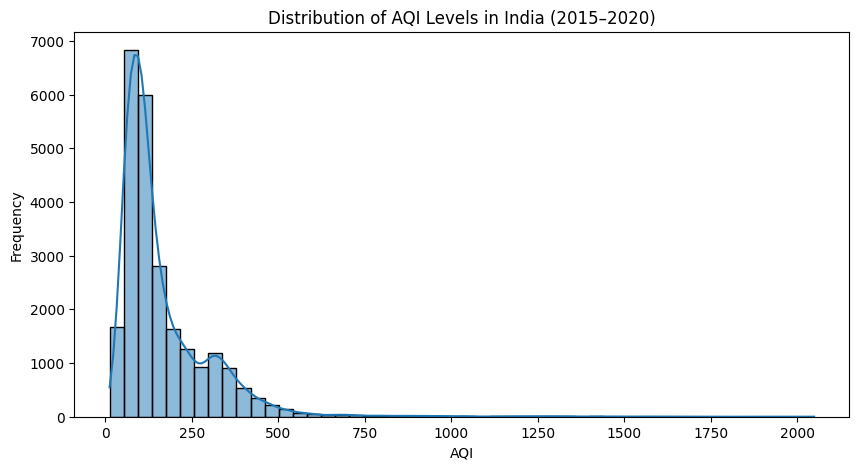

In [17]:
#OVERALL AQI DISTRIBUTION

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_clean["AQI"], bins=50, kde=True)
plt.title("Distribution of AQI Levels in India (2015–2020)")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/aqi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

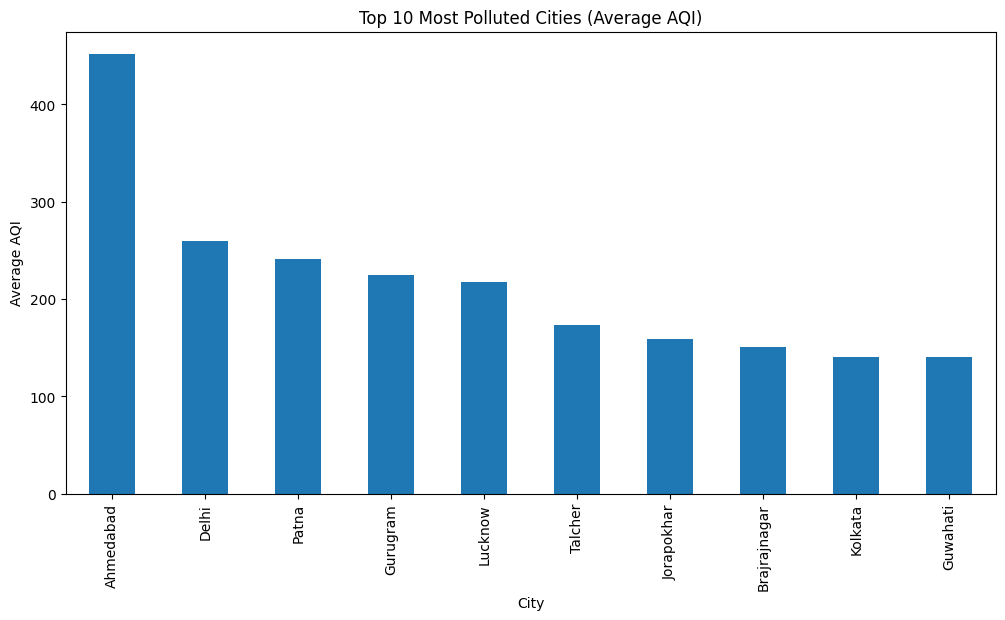

In [18]:
#TOP POLLUTED CITIES

city_avg = df_clean.groupby("City")["AQI"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
city_avg.head(10).plot(kind="bar")
plt.title("Top 10 Most Polluted Cities (Average AQI)")
plt.ylabel("Average AQI")

plt.savefig("../outputs/figures/top_cities.png", dpi=300, bbox_inches="tight")
plt.show()

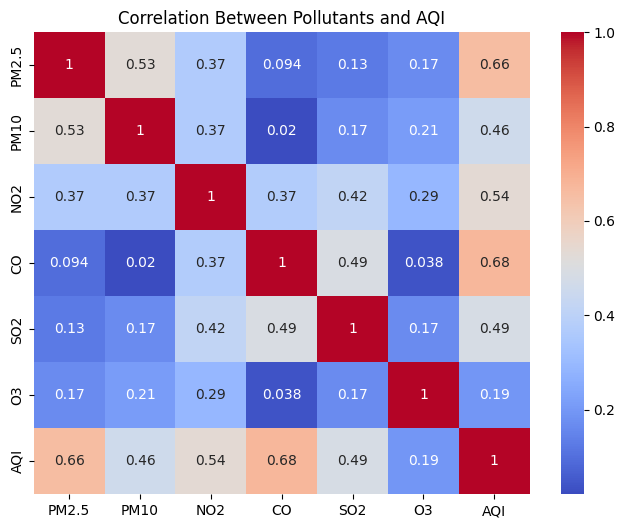

In [19]:
#POLLUTANT IMPACT ANALYSIS

pollutants = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3"]

corr = df_clean[pollutants + ["AQI"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Pollutants and AQI")

plt.savefig("../outputs/figures/correlation.png", dpi=300, bbox_inches="tight")
plt.show()

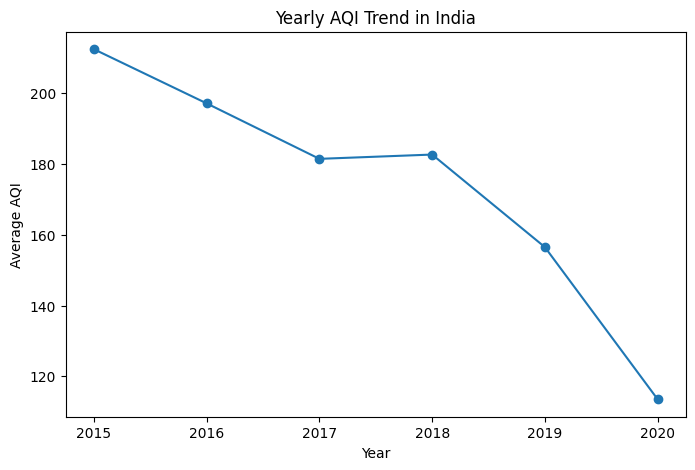

In [28]:
#How pollution changes over time

df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["Year"] = df_clean["Date"].dt.year

yearly_aqi = df_clean.groupby("Year")["AQI"].mean()

plt.figure(figsize=(8,5))
yearly_aqi.plot(marker="o")
plt.title("Yearly AQI Trend in India")
plt.ylabel("Average AQI")

plt.savefig("../outputs/figures/yearly_trend.png", dpi=300, bbox_inches="tight")
plt.show()